# Pipeline perso de preprocessing

In [1]:
import pandas as pd
import os
import nltk
import string
import re
import inflect
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize

In [2]:
#region ntlk downloads
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/antoine/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/antoine/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv("../data/data.csv")

In [4]:
df.head(3)

,index,title,genre,summary
0,0,Drowned Wednesday,fantasy,Drowned Wednesday is the first Trustee among ...
1,1,The Lost Hero,fantasy,"As the book opens, Jason awakens on a school ..."
2,2,The Eyes of the Overworld,fantasy,Cugel is easily persuaded by the merchant Fia...


In [5]:
df['genre'].value_counts()

genre
thriller      1023
fantasy        876
science        647
history        600
horror         600
crime          500
romance        111
psychology     100
sports         100
travel         100
Name: count, dtype: int64

In [6]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
p = inflect.engine()

In [7]:
# 1. Convert to lowercase
def text_lowercase(text):
    return text.lower()

# 2. Remove punctuation
def remove_punctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

# 3. Convert numbers into letters
def convert_number(text):
    temp_str = text.split()
    new_string = []

    for word in temp_str:
        if word.isdigit():
            temp = p.number_to_words(word)
            new_string.append(temp)

        else:
            new_string.append(word)

    temp_str = ' '.join(new_string)
    return temp_str

# 4. remove stopwords
def remove_stopwords(text):
    stop_words = set(stopwords.words("english"))
    word_tokens = word_tokenize(text)
    filtered_text = [word for word in word_tokens if word not in stop_words]
    return filtered_text

# 5. Stemming
def stem_words(text):
    stems = [stemmer.stem(word) for word in text]
    return stems

In [8]:
def preprocess_review(text):
    text = text_lowercase(text)
    text = remove_punctuation(text)
    text = convert_number(text)
    tokens = remove_stopwords(text)
    stems = stem_words(tokens)
    return ' '.join(stems)

In [9]:
# Application de la pipe
print("Prétraitement en cours...")
df_test = df.head(100)

df_test["tokenized_summary"] = df_test["summary"].apply(preprocess_review)

# Sauvegarde des données et export dans Dossier "data"
output_dir= "../data/"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "tokenized_summary.csv")
df_test['tokenized_summary'].to_csv(output_path, index=False)

print(f"Prétraitement terminé. Fichier sauvegardé : {output_path}")

Prétraitement en cours...
Prétraitement terminé. Fichier sauvegardé : ../data/tokenized_summary.csv


/tmp/ipykernel_68026/3496837250.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["tokenized_summary"] = df_test["summary"].apply(preprocess_review)


# TEST

In [10]:
from transformers import pipeline
import torch

classifier = pipeline("zero-shot-classification")
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "politics", "business"],
)

/home/antoine/Documents/Projets_DEV_IA/NLP/Kafkassifier/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.
/home/antoine/Documents/Projets_DEV_IA/NLP/Kafkassifier/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
Device set to use cpu


{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'business', 'politics'],
 'scores': [0.8445994257926941, 0.11197380721569061, 0.04342673346400261]}

In [11]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.7.1+cu126
False


In [12]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", framework="pt")  # <<<<< force PyTorch
result = classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "politics", "business"],
)

print(result)


No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


{'sequence': 'This is a course about the Transformers library', 'labels': ['education', 'business', 'politics'], 'scores': [0.8445994257926941, 0.11197380721569061, 0.04342673346400261]}


In [13]:
from transformers import pipeline

# Load a pre-trained sentiment-analysis model (English)
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

classifier = pipeline("text-classification", model=model_name, tokenizer=model_name)

# Example text
text = "I really enjoyed this movie. It was fantastic and full of suspense!"

# Run classification
result = classifier(text)

print(result)


Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9998835325241089}]


# FINAL TEST

### Step 1 : Import + data loading

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments
import numpy as np
import pickle
from datasets import Dataset
import torch
from transformers import Trainer
import matplotlib.pyplot as plt

df = pd.read_csv("../data/data.csv")  # adapte le nom du fichier
df.head()


/home/antoine/Documents/Projets_DEV_IA/NLP/Kafkassifier/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,index,title,genre,summary
0,0,Drowned Wednesday,fantasy,Drowned Wednesday is the first Trustee among ...
1,1,The Lost Hero,fantasy,"As the book opens, Jason awakens on a school ..."
2,2,The Eyes of the Overworld,fantasy,Cugel is easily persuaded by the merchant Fia...
3,3,Magic's Promise,fantasy,The book opens with Herald-Mage Vanyel return...
4,4,Taran Wanderer,fantasy,Taran and Gurgi have returned to Caer Dallben...


### 1.2. Statistics

In [2]:
print("Dimensions du dataset :", df.shape)
print("\nColonnes :", df.columns.to_list())
print("\nTypes de données :\n", df.dtypes)
print("\nValeurs manquantes :\n", df.isnull().sum())
print("\nDistribution des genres :\n", df['genre'].value_counts())
print("\nNombre de classes de genre :", df['genre'].nunique())

Dimensions du dataset : (4657, 4)

Colonnes : ['index', 'title', 'genre', 'summary']

Types de données :
 index       int64
title      object
genre      object
summary    object
dtype: object

Valeurs manquantes :
 index      0
title      0
genre      0
summary    0
dtype: int64

Distribution des genres :
 genre
thriller      1023
fantasy        876
science        647
history        600
horror         600
crime          500
romance        111
psychology     100
sports         100
travel         100
Name: count, dtype: int64

Nombre de classes de genre : 10


### 1.3.

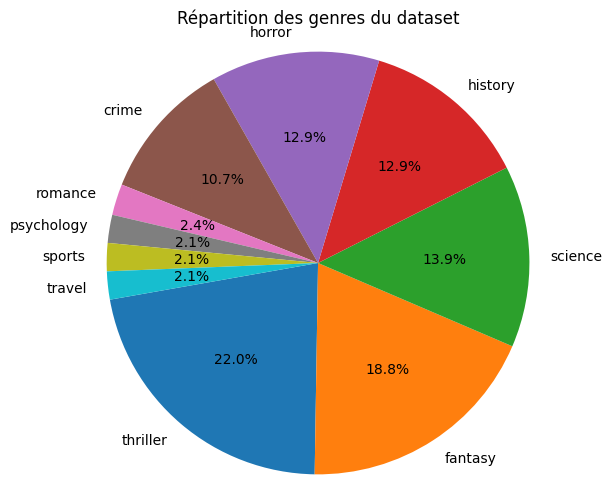

In [3]:
genre_counts = df['genre'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=190)
plt.title("Répartition des genres du dataset")
plt.axis('equal')
plt.show()

### 2.1. Label encoder (-> int)

In [7]:
df['genre'].unique()

array(['fantasy', 'science', 'crime', 'history', 'horror', 'thriller',
       'psychology', 'romance', 'sports', 'travel'], dtype=object)

In [5]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['genre'])

### 2.2. Save label encoder for the inference stage

In [33]:
with open("../model/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

### Step 3 : Convert to Huggingface dataset

In [19]:
from datasets import Dataset

dataset = Dataset.from_pandas(df[['summary', 'label']])  # Conversion en dataset Hugginface


### Step 4 : Tokenization

In [20]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def preprocess_function(examples):
    return tokenizer(examples['summary'], truncation=True, padding='max_length', max_length=256)

tokenized_dataset = dataset.map(preprocess_function, batched=True)

Map: 100%|██████████| 4657/4657 [00:09<00:00, 469.56 examples/s]


### Step 5 : Split dataset

In [21]:
split = tokenized_dataset.train_test_split(test_size=0.2)   # 80/20 (-> small dataset)
train_dataset = split['train']
eval_dataset = split['test']

### STEP 6 : Loading multi-label classifier MODEL

In [22]:
num_labels = len(le.classes_)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_labels)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Step 7 : Metrics

In [23]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}


In [24]:
# 8. Configurer entraînement
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)



In [ ]:
# 9 . Entainement du modele
from transformers import Trainer

trainer = Trainer(
    model=model,               # DistilBERT
    args=training_args,        # config perso
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    
)


/tmp/ipykernel_68026/3484732708.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


### Step 10  : Training and Saving the model

In [26]:
trainer.train()

trainer.save_model("./book_genre_model")
tokenizer.save_pretrained("./book_genre_model")

/home/antoine/Documents/Projets_DEV_IA/NLP/Kafkassifier/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,No log,1.061880
2,No log,0.907610
3,1.151500,0.857099


/home/antoine/Documents/Projets_DEV_IA/NLP/Kafkassifier/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/antoine/Documents/Projets_DEV_IA/NLP/Kafkassifier/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


('./book_genre_model/tokenizer_config.json',
 './book_genre_model/special_tokens_map.json',
 './book_genre_model/vocab.txt',
 './book_genre_model/added_tokens.json',
 './book_genre_model/tokenizer.json')

### Step 11 : Utilisation du modèle

In [37]:
from transformers import pipeline
import pickle

classifier = pipeline("text-classification", model="./book_genre_model", tokenizer="./book_genre_model",return_all_scores=True)

# Recharger le label encoder
with open("../model/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

texts = [
    "A thrilling journey of magic and dragons.",
    "A love story set in the beautiful countryside."
    "A journey to the east riding a van on a road trip on a travel to make memories around the globe in every country",
    "A terrific music festival in Valenciennes eating some Lucullus while listening death melodic metal and headbanging",
    "Paul Atreides, heir to a noble house tasked with ruling the desert planet Arrakis. This planet is the sole source of the Spice, a powerful substance vital for space travel. Betrayed by the Emperor and House Harkonnen, Paul escapes into the desert and joins the Fremen, the native people. With his prophetic abilities and training, he becomes their messiah and leads a revolution to reclaim Arrakis. The novel explores themes of ecology, religion, power, and destiny.",
    "In the mists of the ancient Aegean world, a war raged that would echo through millennia—part legend, part history. The Fall of Troy dives deep into the events behind the myth, unraveling the truth hidden within Homer’s Iliad and other ancient sources. Was there really a city called Troy? Did Helen's abduction spark a war, or was it a clash of empires masked as a love story?",
    "Blending archaeology, ancient texts, and modern scholarship, this book brings to life the siege that inspired poets and shaped Greek identity. Meet the real Achilles, Hektor, and Agamemnon—and discover the political ambitions, economic motives, and cultural myths that fueled one of the most famous conflicts of the ancient world. A gripping retelling and critical analysis, The Fall of Troy explores where myth ends and history begins."
]

# results = classifier(texts)

# print(results)

# Obtenir les prédictions
for text in texts:
    raw_preds = classifier(text)[0]
    decoded_preds = [
        {"label": le.inverse_transform([int(p["label"].split("_")[-1])])[0], "score": p["score"]}
        for p in raw_preds
    ]
    decoded_preds = sorted(decoded_preds, key=lambda x: x["score"], reverse=True)

    print(f"\nTexte : {text}")
    for pred in decoded_preds:
        print(f"→ {pred['label']} : {pred['score']:.2f}")
        



Device set to use cpu
/home/antoine/Documents/Projets_DEV_IA/NLP/Kafkassifier/.venv/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(



Texte : A thrilling journey of magic and dragons.
→ fantasy : 0.89
→ horror : 0.03
→ romance : 0.01
→ science : 0.01
→ thriller : 0.01
→ history : 0.01
→ crime : 0.01
→ travel : 0.01
→ psychology : 0.00
→ sports : 0.00

Texte : A love story set in the beautiful countryside.A journey to the east riding a van on a road trip on a travel to make memories around the globe in every country
→ travel : 0.32
→ thriller : 0.12
→ history : 0.11
→ horror : 0.11
→ romance : 0.07
→ crime : 0.07
→ fantasy : 0.05
→ psychology : 0.05
→ science : 0.05
→ sports : 0.04

Texte : A terrific music festival in Valenciennes eating some Lucullus while listening death melodic metal and headbanging
→ horror : 0.34
→ thriller : 0.16
→ history : 0.09
→ crime : 0.09
→ travel : 0.07
→ fantasy : 0.07
→ science : 0.06
→ romance : 0.05
→ psychology : 0.04
→ sports : 0.03

Texte : Paul Atreides, heir to a noble house tasked with ruling the desert planet Arrakis. This planet is the sole source of the Spice, a powerful su

In [38]:
for text in texts:
    raw_preds = classifier(text)[0]
    decoded_preds = [
        {
            "label": le.inverse_transform([int(p["label"].split("_")[-1])])[0],
            "score": p["score"],
        }
        for p in raw_preds
    ]
    decoded_preds = sorted(decoded_preds, key=lambda x: x["score"], reverse=True)

    print(f"\nTexte : {text}")
    for pred in decoded_preds:
        if pred["score"] > 0.10:
            print(f"Genre : [{pred['label']}] : {pred['score']:.2f}")


Texte : A thrilling journey of magic and dragons.
Genre : [fantasy] : 0.89

Texte : A love story set in the beautiful countryside.A journey to the east riding a van on a road trip on a travel to make memories around the globe in every country
Genre : [travel] : 0.32
Genre : [thriller] : 0.12
Genre : [history] : 0.11
Genre : [horror] : 0.11

Texte : A terrific music festival in Valenciennes eating some Lucullus while listening death melodic metal and headbanging
Genre : [horror] : 0.34
Genre : [thriller] : 0.16

Texte : Paul Atreides, heir to a noble house tasked with ruling the desert planet Arrakis. This planet is the sole source of the Spice, a powerful substance vital for space travel. Betrayed by the Emperor and House Harkonnen, Paul escapes into the desert and joins the Fremen, the native people. With his prophetic abilities and training, he becomes their messiah and leads a revolution to reclaim Arrakis. The novel explores themes of ecology, religion, power, and destiny.
Genre :